# Single-Qubit QuTiP Workshop

**nanoHUB / Python 3.8 edition** · Students learn quantum physics through hands-on QuTiP coding.

Run the cells **in order**. Change only the indicated parameters, rerun the relevant exercise cell, and compare your prediction with the result. 

1. Prepare a qubit: $|0\rangle$, $|1\rangle$, $\pm x$, $\pm y$ from $\theta,\phi$.
2. Change the Hamiltonian: $\Delta$ (diagonal) and $\Omega$ (coupling).
3. Visualize motion on a Bloch sphere.
4. Explore population transfer and Rabi oscillations.

This version uses **QuTiP** objects and solvers rather than custom NumPy matrix evolution. Here $\hbar=1$.

In [ ]:
%pip install --user --force-reinstall --no-deps "Cython==0.29.36"

     |████████████████████████████████| 1.9 MB 9.4 MB/s eta 0:00:01


IMPORTANT: After running the line above, only run it once at the beginning. Click on kernel and then press restart before running the next cells.

In [4]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

print("Python:", sys.version.split()[0])
print("QuTiP:", qt.__version__)

# QuTiP basis states (ket vectors) and operators
zero = qt.basis(2, 0)   # |0>
one  = qt.basis(2, 1)   # |1>

sx = qt.sigmax()
sy = qt.sigmay()
sz = qt.sigmaz()

#print("\n|0>:", zero)
#print("\n|1>:", one)
#print("\nsigma_x:", sx)

Python: 3.8.10
QuTiP: 4.6.2


## 1. Prepare a qubit

Define $|\psi\rangle=\cos(\theta/2)|0\rangle + e^{i\phi}\sin(\theta/2)|1\rangle$. In QuTiP, `basis()` returns a `Qobj`; superpositions are made by adding weighted kets.

In [2]:
# FUNCTION TO CALL in Part 1: state_from_angles(theta, phi)
def state_from_angles(theta, phi):
    """Create a normalized pure qubit state using QuTiP kets."""
    return (np.cos(theta / 2) * zero
            + np.exp(1j * phi) * np.sin(theta / 2) * one).unit()

# FUNCTION TO CALL to inspect coordinates: bloch_coordinates(psi)
def bloch_coordinates(psi):
    """QuTiP calculates <sigma_x>, <sigma_y>, <sigma_z>."""
    return [float(np.real(qt.expect(op, psi))) for op in (sx, sy, sz)]

# FUNCTION TO CALL to draw one state: show_bloch_state(psi)
def show_bloch_state(psi, title="My qubit state"):
    b = qt.Bloch()
    b.add_states(psi)  # QuTiP automatically converts the state into a Bloch vector
    b.title = title
    b.show()

### Exercise 1A — Move the arrow

**Call:** `show_bloch_state()`. Change `theta` and `phi`, then rerun the cell.

State |psi>:
Quantum object: dims = [[2], [1]], shape = (2, 1), type = ket
Qobj data =
[[1.]
 [0.]]
Bloch coordinates [x, y, z]: [0.0, 0.0, 1.0]


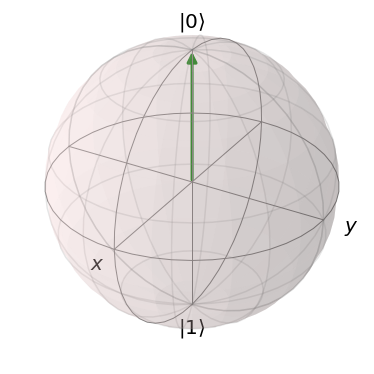

In [3]:
# STUDENTS: CHANGE ONLY THESE TWO VALUES

theta = 0.0
phi = 0.0

psi = state_from_angles(theta, phi)
print("State |psi>:")
print(psi)
print("Bloch coordinates [x, y, z]:", bloch_coordinates(psi))
show_bloch_state(psi)

### Exercise 1B — Find six states

Use the **same cell above** to find $|0\rangle$, $|1\rangle$, $+x$, $-x$, $+y$, and $-y$ by changing the angles.

Questions: What does $\theta$ change? What does $\phi$ change along the equator ($\theta=\pi/2$)? Why are points on the equator equal-weight superpositions? Is the phase physically visible at either pole?

*Optional check:* `qt.expect(sz, psi)` gives the $z$ coordinate; try the other Pauli operators too.

## 2. Change the Hamiltonian

We use $H=\frac{\Delta}{2}\sigma_z+\frac{\Omega}{2}\sigma_x$. The **diagonal** term is controlled by $\Delta$; the **off-diagonal coupling** is controlled by $\Omega$. QuTiP already knows the Pauli matrices—there is no need to type a $2\times2$ NumPy array.

In [5]:
# FUNCTION TO CALL in Parts 2-4: hamiltonian(Delta, Omega)
def hamiltonian(Delta, Omega):
    """Return a QuTiP Qobj Hamiltonian, in units hbar = 1."""
    return 0.5 * Delta * sz + 0.5 * Omega * sx

### Exercise 2 — Inspect three Hamiltonians

**Call:** `hamiltonian(Delta, Omega)`. Try `(1,0)`, `(0,1)`, and `(1,1)`. Which one can mix the basis states? What do its off-diagonal entries look like?

In [6]:
# STUDENTS: CHANGE THESE TWO VALUES
Delta = 1.0
Omega = 0.0

H = hamiltonian(Delta, Omega)
print("Hamiltonian H (QuTiP Qobj):")
print(H)
print("Matrix values:")
print(H.full())

Hamiltonian H (QuTiP Qobj):
Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = True
Qobj data =
[[ 0.5  0. ]
 [ 0.  -0.5]]
Matrix values:
[[ 0.5+0.j  0. +0.j]
 [ 0. +0.j -0.5+0.j]]


## 3. Watch the qubit move

QuTiP’s `sesolve(H, psi0, tlist)` solves the Schrödinger equation for a closed quantum system. `qt.Bloch()` visualizes the path. **You do not have to write a matrix exponential or time-evolution loop.**

In [7]:
# FUNCTION TO CALL: run_dynamics(psi0, H, tmax, nt)
def run_dynamics(psi0, H, tmax=10.0, nt=300):
    """Use QuTiP's Schrodinger-equation solver to obtain states at all times."""
    tlist = np.linspace(0.0, tmax, nt)
    result = qt.sesolve(H, psi0, tlist)
    return tlist, result.states

# FUNCTION TO CALL: show_bloch_trajectory(states)
def show_bloch_trajectory(states, title="Qubit motion"):
    """Get Bloch coordinates via QuTiP and draw a connected trajectory."""
    x = np.real(qt.expect(sx, states))
    y = np.real(qt.expect(sy, states))
    z = np.real(qt.expect(sz, states))

    b = qt.Bloch()
    b.add_points([x, y, z], meth='l')  # 'l' = connected line
    b.add_states(states[0])            # arrow at initial position
    b.title = title
    b.show()
    return x, y, z

### Exercise 3A — Diagonal Hamiltonian

**Call:** `hamiltonian()` → `run_dynamics()` → `show_bloch_trajectory()`.

Start at $+x$ and use $\Delta=1,\Omega=0$. Predict the rotation axis. Then double $\Delta$. Finally, change `psi0 = zero`: does the Bloch arrow move? Why?

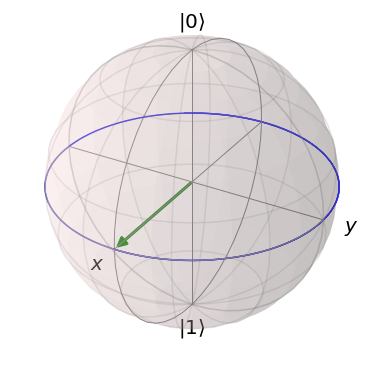

In [8]:
psi0 = state_from_angles(np.pi / 2, 0)  # +x
# psi0 = zero  # Try this after observing +x

Delta = 1.0   # CHANGE THIS
Omega = 0.0   # CHANGE THIS
H = hamiltonian(Delta, Omega)

tlist, states = run_dynamics(psi0, H, tmax=10, nt=300)
x, y, z = show_bloch_trajectory(states, title="3A: Diagonal Hamiltonian")

### Exercise 3B — Off-diagonal coupling

Start at $|0\rangle$. Set $\Delta=0,\Omega=1$. Predict the rotation axis and whether the path reaches the south pole. Try $\Omega=2$.

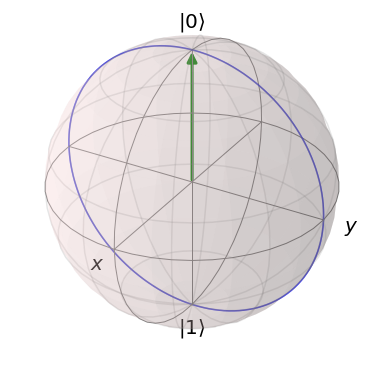

In [9]:
psi0 = zero
Delta = 0.0
Omega = 1.0   # Try 2.0
H = hamiltonian(Delta, Omega)

tlist, states = run_dynamics(psi0, H, tmax=2 * np.pi, nt=300)
x, y, z = show_bloch_trajectory(states, title="3B: Off-diagonal coupling")

### Exercise 3C — Both terms nonzero

Try $\Delta=\Omega=1$, then keep $\Omega=1$ and increase $\Delta$ to 3. Is the rotation axis $x$, $z$, or tilted? Does the trajectory reach $|1\rangle$?

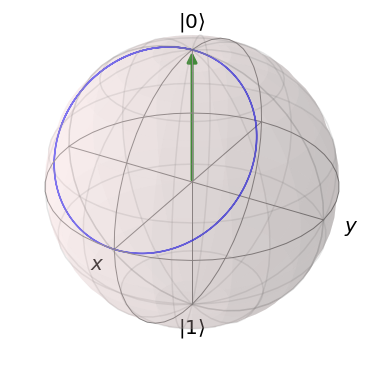

In [10]:
psi0 = zero
Delta = 1.0    # Try 3.0
Omega = 1.0
H = hamiltonian(Delta, Omega)

tlist, states = run_dynamics(psi0, H, tmax=10, nt=400)
x, y, z = show_bloch_trajectory(states, title="3C: Tilted rotation axis")

## 4. Population transfer and Rabi oscillations

The projectors `zero * zero.dag()` and `one * one.dag()` represent measurements of the two basis-state populations. Use QuTiP's `expect()` on the evolved states to get $P_0(t)$ and $P_1(t)$.

In [11]:
# FUNCTION TO CALL: show_populations(psi0, H, tmax, nt)
def show_populations(psi0, H, tmax=4 * np.pi, nt=400):
    """Solve dynamics with QuTiP and plot P(0), P(1)."""
    tlist, states = run_dynamics(psi0, H, tmax=tmax, nt=nt)

    P0_op = zero * zero.dag()  # |0><0|
    P1_op = one * one.dag()    # |1><1|
    P0 = np.real(qt.expect(P0_op, states))
    P1 = np.real(qt.expect(P1_op, states))

    plt.figure(figsize=(8, 4.5))
    plt.plot(tlist, P0, label="P(0)")
    plt.plot(tlist, P1, label="P(1)")
    plt.xlabel("Time (hbar = 1)")
    plt.ylabel("Probability")
    plt.title("Qubit population transfer")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    return tlist, P0, P1

### Exercise 4A — See Rabi oscillations

**Call:** `hamiltonian()` → `show_populations()`. Start at $|0\rangle$ with $\Delta=0,\Omega=1$. Does $P_0(t)+P_1(t)$ remain one? Find the first time $P_1(t)$ reaches one. Compare with $t_\pi=\pi/\Omega$.

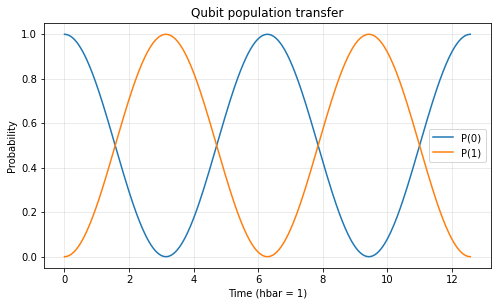

Maximum probability-conservation error: 4.440892098500626e-16
Predicted first pi-pulse time: 3.141592653589793


In [12]:
psi0 = zero
Delta = 0.0
Omega = 1.0
H = hamiltonian(Delta, Omega)

tlist, P0, P1 = show_populations(psi0, H, tmax=4 * np.pi)
print("Maximum probability-conservation error:", np.max(np.abs(P0 + P1 - 1)))
print("Predicted first pi-pulse time:", np.pi / Omega)

### Exercise 4B — Change the coupling strength

Keep `Delta = 0` and `psi0 = zero`; try `Omega = 0.5, 1.0, 2.0`. What happens to the period? Can you predict the first full-transfer time before running?

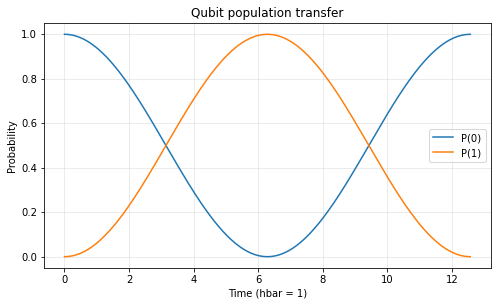

In [13]:
psi0 = zero
Delta = 0.0
Omega = 0.5  # STUDENTS: change to 1.0, then 2.0
H = hamiltonian(Delta, Omega)
tlist, P0, P1 = show_populations(psi0, H, tmax=4 * np.pi)

### Exercise 4C — Add detuning

Keep `Omega = 1` and `psi0 = zero`; try `Delta = 0, 0.5, 1, 3`. Can you still reach `P(1) = 1`? Is the oscillation frequency unchanged? Connect your observation to the tilted axis in Part 3.

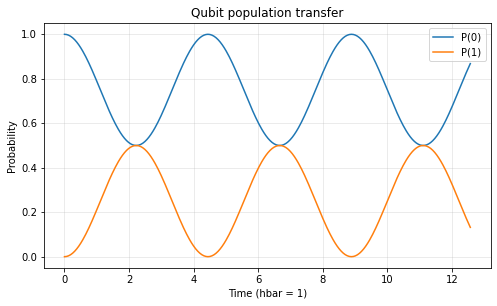

In [14]:
psi0 = zero
Delta = 1.0  # STUDENTS: change to 0, 0.5, 1, 3
Omega = 1.0
H = hamiltonian(Delta, Omega)
tlist, P0, P1 = show_populations(psi0, H, tmax=4 * np.pi)

## Bonus challenges

1. Start at $+x$ with $\Delta=0,\Omega=1$. Why does the Bloch arrow remain fixed, even though the state evolves by a phase?
2. Find an initial state whose Bloch arrow stays fixed when $\Delta=\Omega=1$ (hint: eigenstate of $H$).
3. Change $\Delta$ from $+1$ to $-1$ with $\Omega=0$: how does the direction of rotation change?
4. For $\Delta=3,\Omega=1$, predict the maximum $P_1$ before running the simulation.

**Optional QuTiP exploration:** What is the difference between a ket `psi` and a density matrix `psi * psi.dag()`? Try `qt.expect(sz, psi)` and `qt.expect(sz, psi * psi.dag())`.